# Assignment 7: Exploring Specialized Neural Network Architectures
# Building Convolutional Neural Networks for Image Classification

**Name:** [Baigali Nyamdulam]

**Date:** [03/29/2026]

---

## Setup: Install and Load Libraries

In [6]:
pip install tensorflow matplotlib numpy pandas


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Load and Explore MNIST Dataset

In [2]:
# Load MNIST dataset
print("Loading MNIST dataset...")
(X_train, y_train), (X_test, y_test) = mnist.load_data()


print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Number of classes: {len(np.unique(y_train))}")
print(f"Class labels: {np.unique(y_train)}")

Loading MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training set shape: (60000, 28, 28)
Test set shape: (10000, 28, 28)
Number of classes: 10
Class labels: [0 1 2 3 4 5 6 7 8 9]


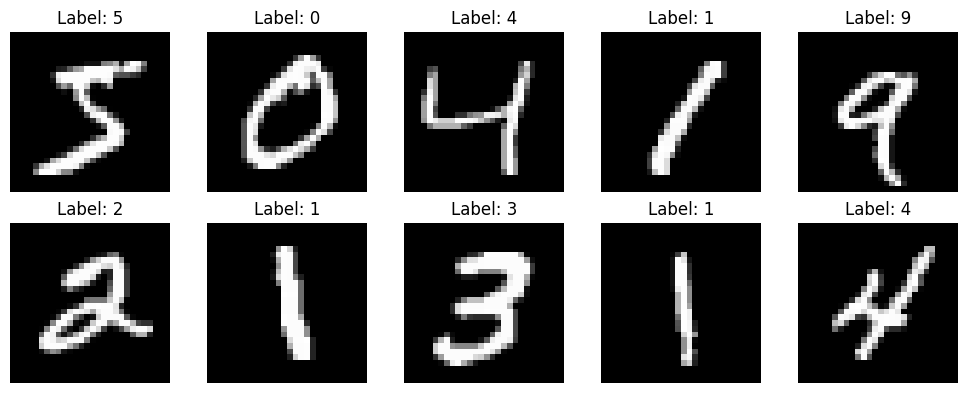

In [3]:
# Visualize sample images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Prepare Data for CNN

In [4]:
# Reshape to add channel dimension (samples, height, width, channels)
X_train_cnn = X_train.reshape(-1, 28, 28, 1).astype('float32')
X_test_cnn = X_test.reshape(-1, 28, 28, 1).astype('float32')

# Normalize pixel values to 0-1 range
X_train_cnn = X_train_cnn / 255.0
X_test_cnn = X_test_cnn / 255.0

print("\n" + "="*80)
print("DATA PREPARED FOR CNN")
print("="*80)
print(f"Training data shape: {X_train_cnn.shape}")
print(f"Test data shape: {X_test_cnn.shape}")
print(f"Pixel value range: [{X_train_cnn.min():.1f}, {X_train_cnn.max():.1f}]")
print("="*80)


DATA PREPARED FOR CNN
Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)
Pixel value range: [0.0, 1.0]


---
## Step 2: Build and Train a Baseline CNN

In [5]:
# TODO: Build your baseline CNN here
# Architecture:
# - Conv2D layer: 32 filters, 3x3 kernel, ReLU activation, input_shape=(28, 28, 1)
# - MaxPooling2D: 2x2 pool size
# - Conv2D layer: 64 filters, 3x3 kernel, ReLU activation
# - MaxPooling2D: 2x2 pool size
# - Flatten layer
# - Dense layer: 128 nodes, ReLU activation
# - Output layer: 10 nodes (digits 0-9), softmax activation

baseline_cnn = keras.Sequential([
    # TODO: Add layers here
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),  # Hidden layer
    layers.Dense(10, activation='softmax')  # Output layer for 10 classes
])

# TODO: Compile the model
# Use Adam optimizer and sparse_categorical_crossentropy loss

baseline_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
baseline_cnn.summary()

c:\Users\Asus\Documents\DTS-RIZE\Assignment-6-Building-Your-First-Neural-Network\tfenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Record training time
print("\nTraining baseline CNN...")
start_time = time.time()

# TODO: Fit the model and store history
history = baseline_cnn.fit(
    X_train, 
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)
  # Replace with actual model fitting
baseline_time = time.time() - start_time

# TODO: Evaluate on test set
baseline_test_loss, baseline_test_acc = baseline_cnn.evaluate(X_test, y_test, verbose=0) # Replace with actual evaluation

print("\n" + "="*80)
print("BASELINE CNN RESULTS")
print("="*80)
# Print final training accuracy, validation accuracy, test accuracy, training time
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {baseline_test_acc:.4f}")
print(f"Training Time: {baseline_time:.2f} seconds")
print("="*80)


Training baseline CNN...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.9053 - loss: 0.8919 - val_accuracy: 0.9701 - val_loss: 0.1044
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step - accuracy: 0.9785 - loss: 0.0700 - val_accuracy: 0.9759 - val_loss: 0.0892
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.9860 - loss: 0.0438 - val_accuracy: 0.9820 - val_loss: 0.0659
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.9893 - loss: 0.0321 - val_accuracy: 0.9838 - val_loss: 0.0617
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.9930 - loss: 0.0221 - val_accuracy: 0.9858 - val_loss: 0.0577
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.9938 - loss: 0.0188 - val_accuracy: 0.9858 - val_loss: 0.0620
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.9944 - loss: 0.0161 - val_accuracy: 0.9853 - val_loss: 0.0638
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy

---
## Step 3: Experiment with Filter Counts

In [ ]:
# TODO: Build and train CNN with FEWER filters (16, 32)
# Keep all other architecture elements the same as baseline
fewer_filters_cnn = keras.Sequential([
    # TODO: Add layers here
    layers.Conv2D(filters=16, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),  # Hidden layer
    layers.Dense(10, activation='softmax')  # Output layer for 10 classes
])
# Use Adam optimizer and sparse_categorical_crossentropy loss

fewer_filters_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Training CNN with fewer filters (16, 32)...")
# TODO: Build, compile, and train model
# Record validation accuracy
start_time_1 = time.time()

# TODO: Fit the model and store history
history_fewer_filters = fewer_filters_cnn.fit(
    X_train, 
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)
  # Replace with actual model fitting
fewer_filters_time = time.time() - start_time_1

# TODO: Evaluate on test set
fewer_filters_test_loss, fewer_filters_test_acc = fewer_filters_cnn.evaluate(X_test, y_test, verbose=0) # Replace with actual evaluation

print("\n" + "="*80)
print("Fewer Filters CNN RESULTS")
print("="*80)
# Print final training accuracy, validation accuracy, test accuracy, training time
print(f"Final Training Accuracy: {history_fewer_filters.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history_fewer_filters.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {fewer_filters_test_acc:.4f}")
print(f"Training Time: {fewer_filters_time:.2f} seconds")
print("="*80)

Training CNN with fewer filters (16, 32)...
Epoch 1/10


c:\Users\Asus\Documents\DTS-RIZE\Assignment-6-Building-Your-First-Neural-Network\tfenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9063 - loss: 0.7655 - val_accuracy: 0.9622 - val_loss: 0.1337
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9741 - loss: 0.0919 - val_accuracy: 0.9734 - val_loss: 0.0947
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9838 - loss: 0.0560 - val_accuracy: 0.9769 - val_loss: 0.0951
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9888 - loss: 0.0365 - val_accuracy: 0.9762 - val_loss: 0.0828
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9924 - loss: 0.0248 - val_accuracy: 0.9801 - val_loss: 0.0775
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9934 - loss: 0.0201 - val_accuracy: 0.9807 - val_loss: 0.0767
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9938 - loss: 0.0184 - val_accuracy: 0.9779 - val_loss: 0.0938
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9940 - loss: 0.0191 - val_accuracy: 0.981

In [ ]:
# TODO: Build and train CNN with MORE filters (64, 128)
# Keep all other architecture elements the same as baseline
more_filters_cnn = keras.Sequential([
    # TODO: Add layers here
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(filters=128, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),  # Hidden layer
    layers.Dense(10, activation='softmax')  # Output layer for 10 classes
])

# Use Adam optimizer and sparse_categorical_crossentropy loss

more_filters_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Training CNN with more filters (64, 128)...")
# TODO: Build, compile, and train model
# Record validation accuracy

start_time_2 = time.time()
history_more_filters = more_filters_cnn.fit(
    X_train, 
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)
  # Replace with actual model fitting
more_filters_time = time.time() - start_time_2

# TODO: Evaluate on test set
more_filters_test_loss, more_filters_test_acc = more_filters_cnn.evaluate(X_test, y_test, verbose=0) # Replace with actual evaluation

print("\n" + "="*80)
print("More Filters CNN RESULTS")
print("="*80)
# Print final training accuracy, validation accuracy, test accuracy, training time
print(f"Final Training Accuracy: {history_more_filters.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history_more_filters.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {more_filters_test_acc:.4f}")
print(f"Training Time: {more_filters_time:.2f} seconds")
print("="*80)

Training CNN with more filters (64, 128)...
Epoch 1/10


c:\Users\Asus\Documents\DTS-RIZE\Assignment-6-Building-Your-First-Neural-Network\tfenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


375/375 ━━━━━━━━━━━━━━━━━━━━ 34s 86ms/step - accuracy: 0.9218 - loss: 0.9196 - val_accuracy: 0.9803 - val_loss: 0.0677
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 31s 82ms/step - accuracy: 0.9822 - loss: 0.0560 - val_accuracy: 0.9844 - val_loss: 0.0565
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 32s 84ms/step - accuracy: 0.9871 - loss: 0.0403 - val_accuracy: 0.9842 - val_loss: 0.0528
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 31s 82ms/step - accuracy: 0.9903 - loss: 0.0294 - val_accuracy: 0.9843 - val_loss: 0.0576
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 31s 83ms/step - accuracy: 0.9924 - loss: 0.0243 - val_accuracy: 0.9858 - val_loss: 0.0481
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 33s 88ms/step - accuracy: 0.9948 - loss: 0.0168 - val_accuracy: 0.9858 - val_loss: 0.0536
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 33s 89ms/step - accuracy: 0.9942 - loss: 0.0179 - val_accuracy: 0.9868 - val_loss: 0.0535
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 32s 85ms/step - accuracy: 0.9944 - loss: 0.0174 - val_accurac

### Analysis: Filter Count Effects

**TODO: Write 2-3 sentences answering:**
- As the number of filters increase, the accuracy mostly increases. I'm saying mostly because the baseline accuracies are slightly less than those of the model with fewer filters.
- However, the increase in time that it takes to train the models with more filters do not justify the negligible improvement in accuracy.

---
## Step 4: Experiment with Kernel Sizes

In [9]:
# TODO: Build and train CNN with MEDIUM kernels (5x5 for both layers)
# Keep filter counts at baseline (32, 64)
kernel_1_cnn = keras.Sequential([
    # TODO: Add layers here
    layers.Conv2D(filters=32, kernel_size=(5, 5), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(filters=64, kernel_size=(5, 5), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),  # Hidden layer
    layers.Dense(10, activation='softmax')  # Output layer for 10 classes
])

kernel_1_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Training CNN with 5x5 kernels...")
# TODO: Build, compile, and train model
# Record validation accuracy
start_time_3 = time.time()
history_kernel_1 = kernel_1_cnn.fit(
    X_train, 
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)
  # Replace with actual model fitting
kernel_1_time = time.time() - start_time_3

# TODO: Evaluate on test set
kernel_1_test_loss, kernel_1_test_acc = kernel_1_cnn.evaluate(X_test, y_test, verbose=0) # Replace with actual evaluation

print("\n" + "="*80)
print("Kernel Option #1 (5x5) CNN RESULTS")
print("="*80)
# Print final training accuracy, validation accuracy, test accuracy, training time
print(f"Final Training Accuracy: {history_kernel_1.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history_kernel_1.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {kernel_1_test_acc:.4f}")
print(f"Training Time: {kernel_1_time:.2f} seconds")
print("="*80)

Training CNN with 5x5 kernels...
Epoch 1/10


c:\Users\Asus\Documents\DTS-RIZE\Assignment-6-Building-Your-First-Neural-Network\tfenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.9028 - loss: 0.8550 - val_accuracy: 0.9721 - val_loss: 0.0955
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.9791 - loss: 0.0686 - val_accuracy: 0.9783 - val_loss: 0.0763
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.9866 - loss: 0.0444 - val_accuracy: 0.9790 - val_loss: 0.0699
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.9894 - loss: 0.0328 - val_accuracy: 0.9838 - val_loss: 0.0671
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.9908 - loss: 0.0277 - val_accuracy: 0.9804 - val_loss: 0.0842
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.9922 - loss: 0.0233 - val_accuracy: 0.9839 - val_loss: 0.0629
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.9923 - loss: 0.0242 - val_accuracy: 0.9853 - val_loss: 0.0647
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.9925 - loss: 0.0219 - val_accurac

In [10]:
# TODO: Build and train CNN with MIXED kernels (5x5 first layer, 3x3 second layer)
# Keep filter counts at baseline (32, 64)
kernel_2_cnn = keras.Sequential([
    # TODO: Add layers here
    layers.Conv2D(filters=32, kernel_size=(5, 5), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),  # Hidden layer
    layers.Dense(10, activation='softmax')  # Output layer for 10 classes
])

kernel_2_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Training CNN with mixed kernels (5x5, 3x3)...")
# TODO: Build, compile, and train model
# Record validation accuracy

start_time_4 = time.time()
history_kernel_2 = kernel_2_cnn.fit(
    X_train, 
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)
  # Replace with actual model fitting
kernel_2_time = time.time() - start_time_4

# TODO: Evaluate on test set
kernel_2_test_loss, kernel_2_test_acc = kernel_2_cnn.evaluate(X_test, y_test, verbose=0) # Replace with actual evaluation

print("\n" + "="*80)
print("Kernel Option #2 (5x5 & 3x3) CNN RESULTS")
print("="*80)
# Print final training accuracy, validation accuracy, test accuracy, training time
print(f"Final Training Accuracy: {history_kernel_2.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history_kernel_2.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {kernel_2_test_acc:.4f}")
print(f"Training Time: {kernel_2_time:.2f} seconds")
print("="*80)

Training CNN with mixed kernels (5x5, 3x3)...
Epoch 1/10


c:\Users\Asus\Documents\DTS-RIZE\Assignment-6-Building-Your-First-Neural-Network\tfenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.9209 - loss: 0.7330 - val_accuracy: 0.9739 - val_loss: 0.0881
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.9820 - loss: 0.0600 - val_accuracy: 0.9793 - val_loss: 0.0746
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.9882 - loss: 0.0393 - val_accuracy: 0.9795 - val_loss: 0.0773
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9907 - loss: 0.0286 - val_accuracy: 0.9833 - val_loss: 0.0645
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9928 - loss: 0.0224 - val_accuracy: 0.9808 - val_loss: 0.0736
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.9937 - loss: 0.0197 - val_accuracy: 0.9844 - val_loss: 0.0662
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9954 - loss: 0.0140 - val_accuracy: 0.9828 - val_loss: 0.0746
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.9938 - loss: 0.0198 - val_accuracy

### Analysis: Kernel Size Effects

**TODO: Write 2-3 sentences answering:**
- How does kernel size affect what the network learns?
- Which kernel configuration performed best and why might that be?

[Kernel size bascially tells the size of the area each filter is going to look at at the same time. 5x5 would mean 25 pixels and 3x3 would mean 9 pixels. The mixed kernel option where the initial layer looked at larger area (5x5) and the later layer looked at smaller area (3x3) performed the best considering efficiency. The reason could be due to the fact that opting for smaller or larger areas solely might have caused each options to lose points on efficiency (3x3) and miss details (5x5).]

---
## Step 5: Train Your Best Architecture and Visualize Learning

In [16]:
# TODO: Based on your experiments, build your best-performing CNN architecture
# Train for 15 epochs with 20% validation split
best_cnn = keras.Sequential([
    # TODO: Add layers here
    layers.Conv2D(filters=16, kernel_size=(5, 5), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),  # Hidden layer
    layers.Dense(10, activation='softmax')  # Output layer for 10 classes
])
# Use Adam optimizer and sparse_categorical_crossentropy loss

best_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training best CNN architecture...")
# TODO: Build, compile, and train model
# Record validation accuracy
start_time_5 = time.time()

# TODO: Fit the model and store history
history_best = best_cnn.fit(
    X_train, 
    y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)
  # Replace with actual model fitting
best_time = time.time() - start_time_5

# TODO: Evaluate on test set
best_test_loss, best_test_acc = best_cnn.evaluate(X_test, y_test, verbose=0) # Replace with actual evaluation

print("\n" + "="*80)
print("Best CNN RESULTS")
print("="*80)
# Print final training accuracy, validation accuracy, test accuracy, training time
print(f"Final Training Accuracy: {history_best.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history_best.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {best_test_acc:.4f}")
print(f"Training Time: {best_time:.2f} seconds")
print("="*80)

Training best CNN architecture...
Epoch 1/15


c:\Users\Asus\Documents\DTS-RIZE\Assignment-6-Building-Your-First-Neural-Network\tfenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8909 - loss: 1.0448 - val_accuracy: 0.9635 - val_loss: 0.1260
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9720 - loss: 0.0962 - val_accuracy: 0.9751 - val_loss: 0.0893
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9819 - loss: 0.0594 - val_accuracy: 0.9791 - val_loss: 0.0802
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9872 - loss: 0.0394 - val_accuracy: 0.9824 - val_loss: 0.0683
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9905 - loss: 0.0296 - val_accuracy: 0.9823 - val_loss: 0.0679
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9926 - loss: 0.0229 - val_accuracy: 0.9827 - val_loss: 0.0768
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9929 - loss: 0.0203 - val_accuracy: 0.9837 - val_loss: 0.0726
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9918 - loss: 0.0241 - val_accuracy: 0.98

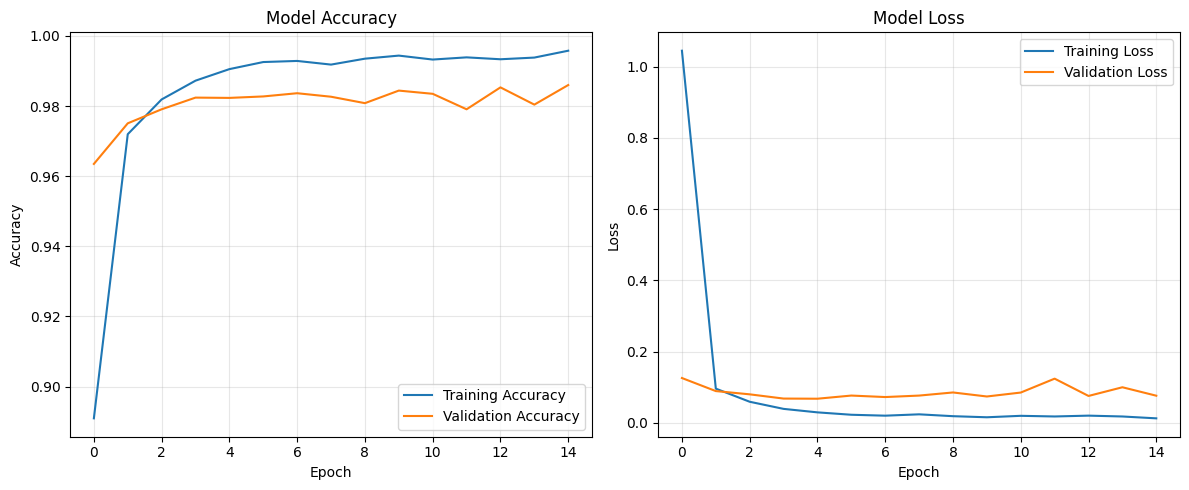

In [17]:
# TODO: Create accuracy plot (training vs validation accuracy over epochs)

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
# TODO: Plot training and validation accuracy
plt.plot(history_best.history['accuracy'], label='Training Accuracy')
plt.plot(history_best.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss plot
plt.subplot(1, 2, 2)
# TODO: Plot training and validation loss
plt.plot(history_best.history['loss'], label='Training Loss')
plt.plot(history_best.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Step 6: Compare Against Feedforward Network

In [19]:
# Prepare data for feedforward network (flatten images)
X_train_flat = X_train.reshape(-1, 784).astype('float32') / 255.0
X_test_flat = X_test.reshape(-1, 784).astype('float32') / 255.0
print(f"Flattened training data shape: {X_train_flat.shape}")
print(f"Flattened test data shape: {X_test_flat.shape}")

Flattened training data shape: (60000, 784)
Flattened test data shape: (10000, 784)


In [20]:
# TODO: Build feedforward network
# Architecture:
# - Input: 784 features (flattened 28x28 image)
# - Dense layer: 128 nodes, ReLU activation
# - Dense layer: 64 nodes, ReLU activation
# - Output layer: 10 nodes, softmax activation

feedforward_nn = keras.Sequential([
    # TODO: Add layers here
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),  # First hidden layer
    layers.Dense(64, activation='relu'),   # Second hidden layer
    layers.Dense(10, activation='softmax')
])

# TODO: Compile the model
feedforward_nn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
feedforward_nn.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Record training time
print("Training feedforward network...")
start_time = time.time()

# TODO: Train feedforward network for 10 epochs
# Fit the model

ff_network_history = feedforward_nn.fit(
    X_train_flat, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=0
)

# Record training time
feedforward_time = time.time() - start_time

# TODO: Evaluate on test set

ff_network_loss, ff_network_accuracy = feedforward_nn.evaluate(X_test_flat, y_test, verbose=0)

Training feedforward network...


In [22]:
# TODO: Create comparison table

comparison_data = {
    'Model': ['Baseline CNN', 'Best CNN', 'Feedforward NN'],
    'Architecture': [
        # TODO: Fill in architecture details
        "32 & 64 filters and (3x3)", '16 & 32 Filters and (5x5) & (3x3)', 'Simple Feed forward nn with 128 & 64 neurons'
    ],
    'Test Accuracy': [
        # TODO: Fill in test accuracies
        baseline_test_acc, best_test_acc, ff_network_accuracy
    ],
    'Training Time (s)': [
        # TODO: Fill in training times
        baseline_time, best_time, feedforward_time
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)


MODEL COMPARISON
         Model                                 Architecture  Test Accuracy  Training Time (s)
  Baseline CNN                    32 & 64 filters and (3x3)         0.9825         145.452396
      Best CNN            16 & 32 Filters and (5x5) & (3x3)         0.9858         100.216502
Feedforward NN Simple Feed forward nn with 128 & 64 neurons         0.9745          24.999589


### Analysis: CNN vs Feedforward Network

**TODO: Write 2-3 sentences answering:**
- How does your best CNN compare to the feedforward network on image data?
- Why does the CNN's spatial awareness lead to better performance than treating pixels as independent features?

[My best CNN performs better in accuracy by 0.0113 points compared to the Feedforward NN, but takes 4 times more time to train. Because treating individual pixels do not help when the two images are of similar kind but different, spatial awareness helps the algorithm distinguish that difference.]

---
## Step 7: Reflect on Specialized Architectures for Your Final Project

### Final Project Application

**TODO: Write 3-4 sentences answering:**
- Based on your Unit 9 final project proposal, would CNNs or RNNs enhance your project? Why or why not?
- If your project uses tabular data (customer demographics, transaction records), explain why feedforward networks or traditional ML models remain appropriate.
- If your project could benefit from specialized architectures (images, time series, text), describe specifically how CNNs or RNNs would improve your solution compared to the approaches you've planned.

[Considering the amount of time it will take to train the models, I don't think RNNs will help me with my project. My data is tabular and is clearly labeled, and my project will require a high level of interpretability. As such, there is no need to overcomplicate things. If I ever decide to go with RNN, most probably the accuracy will improve by a small percentage which might be useful. I will have to work with my data to see that. ]

---
## Submission Checklist

Before submitting, ensure you have:
- [ ] Built and trained baseline CNN (2 conv layers)
- [ ] Conducted at least 3 architecture experiments (filter counts and kernel sizes)
- [ ] Trained best CNN architecture for 15 epochs
- [ ] Created accuracy and loss plots for best model
- [ ] Built and trained feedforward network for comparison
- [ ] Created comparison table with all models
- [ ] Answered all analysis questions in Markdown cells
- [ ] Written reflection on final project application
- [ ] Pushed code to GitHub repository
- [ ] Submitted GitHub repository link to assignment

---
## Step 8: Submit Your Work
Push to GitHub:
```bash
git add .
git commit -m 'completed CNN architecture assignment'
git push
```

Submit your GitHub repository link on the course platform.